In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

Formatted image shape: (224, 224)


array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [182, 170, 166, ..., 173, 177, 178],
       [173, 165, 174, ..., 173, 177, 178],
       [169, 167, 177, ..., 172, 176, 179]], dtype=uint8)
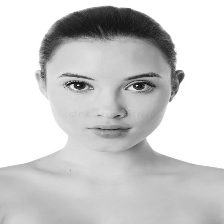

In [2]:
import cv2
import numpy as np
import urllib.request
url = "https://thumbs.dreamstime.com/b/beauty-woman-face-13425892.jpg"

resp = urllib.request.urlopen(url)
image_np = np.asarray(bytearray(resp.read()), dtype=np.uint8)
img = cv2.imdecode(image_np, cv2.IMREAD_COLOR)

if img is None:
    raise ValueError("Image not loaded")
img_resized = cv2.resize(img, (224, 224))
RGB = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
gray=cv2.cvtColor(RGB, cv2.COLOR_BGR2GRAY )
gray_norm = gray.astype("float32") / 255.0

print("Formatted image shape:", gray_norm.shape)
gray


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

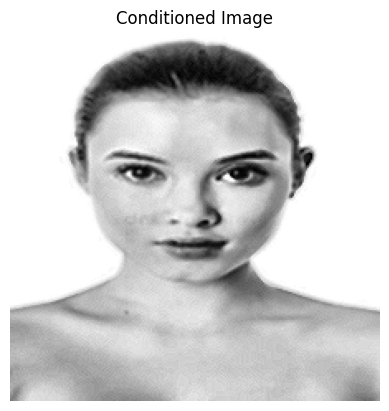

In [3]:
denoised = cv2.GaussianBlur(gray, (5, 5), 0)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
contrast = clahe.apply(denoised)

kernel = np.array([[0, -1, 0],
                   [-1, 5, -1],
                   [0, -1, 0]])
conditioned = cv2.filter2D(contrast, -1, kernel)

plt.imshow(conditioned, cmap="gray")
plt.title("Conditioned Image")
plt.axis("off")


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

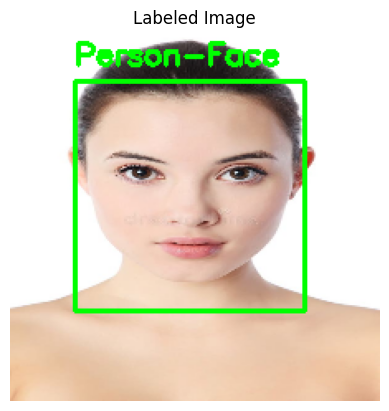

In [4]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

faces = face_cascade.detectMultiScale(
    conditioned,
    scaleFactor=1.1,
    minNeighbors=5
)

labeled_img = img_resized.copy()

for (x, y, w, h) in faces:
    cv2.rectangle(labeled_img, (x, y), (x + w, y + h), (0, 255, 0), 2)
    cv2.putText(labeled_img, "Person-Face", (x, y - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

plt.imshow(cv2.cvtColor(labeled_img, cv2.COLOR_BGR2RGB))
plt.title("Labeled Image")
plt.axis("off")


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

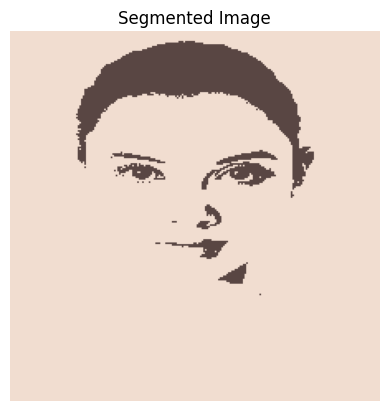

In [5]:
pixel_values = img_resized.reshape((-1, 3))
pixel_values = np.float32(pixel_values)

k = 2
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
_, labels, centers = cv2.kmeans(
    pixel_values, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS
)

centers = np.uint8(centers)
segmented_img = centers[labels.flatten()]
segmented_img = segmented_img.reshape(img_resized.shape)

plt.imshow(cv2.cvtColor(segmented_img, cv2.COLOR_BGR2RGB))
plt.title("Segmented Image")
plt.axis("off")


Number of keypoints detected: 599


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

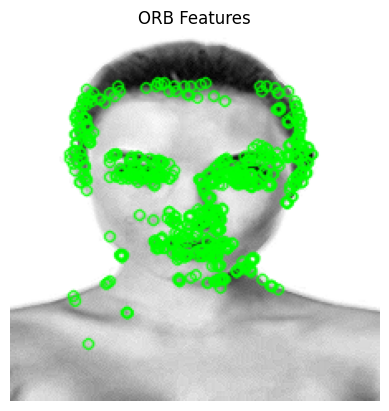

In [6]:
orb = cv2.ORB_create(nfeatures=1000)

keypoints, descriptors = orb.detectAndCompute(conditioned, None)

print("Number of keypoints detected:", len(keypoints))

orb_img = cv2.drawKeypoints(
    conditioned, keypoints, None, color=(0, 255, 0)
)

plt.imshow(orb_img, cmap="gray")
plt.title("ORB Features")
plt.axis("off")


In [7]:
from sklearn.datasets import fetch_olivetti_faces
import cv2
import numpy as np
import matplotlib.pyplot as plt

data = fetch_olivetti_faces()

images = data.images
targets = data.target


downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


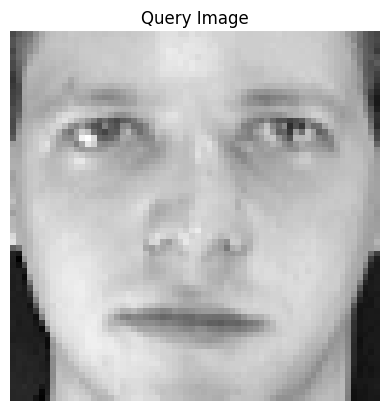

In [8]:
query_img = (images[0] * 255).astype("uint8")

plt.imshow(query_img, cmap="gray")
plt.title("Query Image")
plt.axis("off")
plt.show()


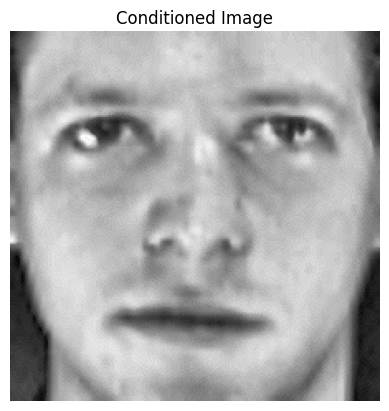

In [9]:
formatted = cv2.resize(query_img, (224,224))

denoised = cv2.GaussianBlur(formatted, (5,5), 0)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
contrast = clahe.apply(denoised)

kernel = np.array([[0,-1,0],
                   [-1,5,-1],
                   [0,-1,0]])

conditioned = cv2.filter2D(contrast, -1, kernel)

plt.imshow(conditioned, cmap="gray")
plt.title("Conditioned Image")
plt.axis("off")
plt.show()


In [10]:
img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
img_gray = cv2.resize(img_gray, (64, 64))
img_gray = img_gray.astype("float32") / 255.0
feature1 = img_gray.flatten().reshape(1, -1)

In [11]:
data = fetch_olivetti_faces()
images = data.images
olivetti_img = images[10]
feature2 = olivetti_img.flatten().reshape(1, -1)

In [13]:
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import euclidean

data = fetch_olivetti_faces()
images = data.images
index = 12
olivetti_img = images[index]
feature2 = olivetti_img.flatten().reshape(1, -1)
cos_score = cosine_similarity(feature1, feature2)[0][0]
euc_score = euclidean(feature1.flatten(), feature2.flatten())

In [14]:
data = fetch_olivetti_faces()
images = data.images
index = 11
olivetti_img2 = images[index]
feature2 = olivetti_img.flatten().reshape(1, -1)
cos_score = cosine_similarity(feature1, feature2)[0][0]
euc_score = euclidean(feature1.flatten(), feature2.flatten())

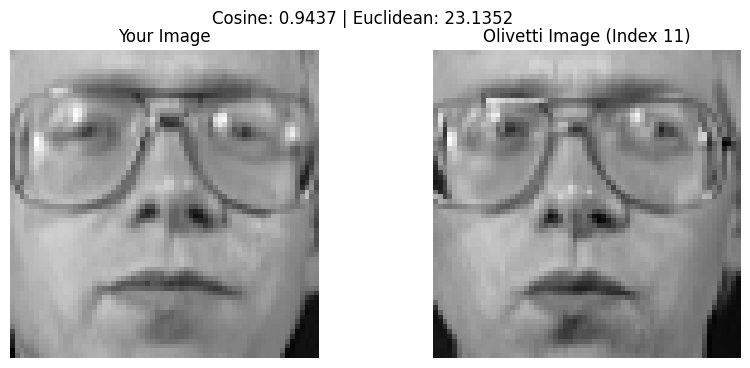

In [15]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(olivetti_img2, cmap='gray')
plt.title("Your Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(olivetti_img, cmap='gray')
plt.title(f"Olivetti Image (Index {index})")
plt.axis("off")

plt.suptitle(f"Cosine: {cos_score:.4f} | Euclidean: {euc_score:.4f}")
plt.show()